#### Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Import datasets

In [2]:
train= pd.read_parquet("train.parquet")
test= pd.read_parquet("inference.parquet")
product_features = pd.read_parquet("expected_minutes.parquet")
calendar = pd.read_parquet("calendar.parquet")
capacity  = pd.read_parquet("capacity.parquet")

### Data preprocessing

#### Date Time conversion

In [3]:
train["kit_start"]     = pd.to_datetime(train["kit_start"])
train["kit_end"]       = pd.to_datetime(train["kit_end"])
train["download_date"] = pd.to_datetime(train["download_date"])

test["kit_start"]      = pd.to_datetime(test["kit_start"])
test["download_date"]  = pd.to_datetime(test["download_date"])

calendar["date"] = pd.to_datetime(calendar["date"])
capacity["date"]  = pd.to_datetime(capacity["date"])

#### Data overview

In [4]:
# Analysing data shapes
print(f"Train data: {train.shape}")
print(f"Test data: {test.shape}")
print(f"Product features data: {product_features.shape}")
print(f"Calendar data: {calendar.shape}")
print(f"Capacity data : {capacity.shape}")

# Check Train date range
print(f"\nkit_start : {train['kit_start'].min().date()}  to  {train['kit_start'].max().date()}\n")

# Check for Missing values in train
print(train.isnull().sum()[train.isnull().sum() > 0])

Train data: (179853, 19)
Test data: (12069, 18)
Product features data: (260, 4)
Calendar data: (370, 17)
Capacity data : (191934, 4)

kit_start : 2025-03-04  to  2026-01-31

download_date    5
dtype: int64


#### Handle missing values

In [5]:
train = train.dropna(subset=["download_date"]).copy()

#### Check and remobve invalid rows based on kit start and kit end

In [6]:
train = train[train["kit_end"] >= train["kit_start"]].copy()

#### Remove data where quantity < 0

In [7]:
train["quantity_produced"] = pd.to_numeric(train["quantity_produced"], errors="coerce")
train = train[train["quantity_produced"] > 0].copy()

In [8]:
print(f"Training row count after data cleaning: {len(train)}")

Training row count after data cleaning: 179110


### Data Merging

#### Convert to string and remove spaces

In [9]:
for df in [train, test, product_features]:
    df["family_desc"] = df["family_desc"].astype(str).str.strip()

#### Calculate 'download_to_kitstart_days' feature before merge

In [10]:
train["download_to_kitstart_days"] = (
    train["kit_start"] - train["download_date"]
).dt.days.clip(lower=0)

test["download_to_kitstart_days"] = (
    test["kit_start"] - test["download_date"]
).dt.days.clip(lower=0)

#### Merge on Product Features

In [11]:
train = train.merge(product_features, on="family_desc", how="left")
test  = test.merge(product_features, on="family_desc", how="left")

In [12]:
# Check for missing values after merge
# train.isna().sum()

In [13]:
# Check for missing values after merge
# test.isna().sum()

#### Impute with median values for product features

In [14]:
for col in ["expected_kit_minutes", "expected_build_minutes", "expected_burn_minutes"]:
      missing_pct = train[col].isnull().sum() / len(train) * 100
      print(f"{col}: {missing_pct:.1f}% missing")


expected_kit_minutes: 24.5% missing
expected_build_minutes: 24.5% missing
expected_burn_minutes: 29.2% missing


In [15]:
expected_cols = ["expected_kit_minutes", "expected_build_minutes", "expected_burn_minutes"]

for col in expected_cols:
    train[col] = pd.to_numeric(train[col], errors="coerce")
    test[col]  = pd.to_numeric(test[col],  errors="coerce")
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)

#### Merging on Calendar data

In [16]:
# Selecting useful columns from the Calender dataset and merge
calendar_cols = [
    "date",
    "is_weekend",
    "is_holiday",
    "is_idc",
    "is_eoq",
    "calendar_weeknum",
    "calendar_month",
    "calendar_year",
    "day_of_week"
]

calendar = calendar[calendar_cols].copy()

train = train.merge(calendar, left_on="kit_start", right_on="date", how="left")
test  = test.merge(calendar, left_on="kit_start", right_on="date", how="left")

train = train.drop(columns=["date"], errors="ignore")
test  = test.drop(columns=["date"], errors="ignore")

In [17]:
# Check for null values
# test.isna().sum()
# train.isna().sum()

In [18]:
# NA values are filled with 0 for binary features
for col in ["is_weekend", "is_holiday", "is_idc", "is_eoq"]:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(0)

# Impute missing data with median
for col in ["calendar_weeknum", "calendar_month", "calendar_year", "day_of_week"]:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)

#### Merging on Capacity Data

In [19]:
# Capacity has more columns than Train Data, need to address duplicates by sum or max aggregation.
capacity = capacity.groupby("date", as_index=False).agg({
    "regular_hours": "sum",
    "ot_hours":      "sum",
    "ot_flag":       "max"
})

train = train.merge(capacity, left_on="kit_start", right_on="date", how="left")
test  = test.merge(capacity, left_on="kit_start", right_on="date", how="left")

train = train.drop(columns=["date"], errors="ignore")
test  = test.drop(columns=["date"], errors="ignore")

In [20]:
# checking and Handling missing values
# print(test.isna().sum())
# print(train.isna().sum())

for col in ["regular_hours", "ot_hours", "ot_flag"]:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(0)

In [21]:
# Encoding Categorical features
cat_cols = ["family_desc", "family_parent_desc", "lob_desc", "buid", "alt_type_desc"]

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat(
        [train[col].astype(str), test[col].astype(str)], ignore_index=True
    )
    le.fit(combined)
    train[col + "_enc"] = le.transform(train[col].astype(str))
    test[col + "_enc"]  = le.transform(test[col].astype(str))

### Create Target Variable

In [22]:
train["cycle_time_days"] = (train["kit_end"] - train["kit_start"]).dt.days

train = train[train["cycle_time_days"] >= 0].copy()

In [23]:
train["cycle_time_days"].describe()

count    179110.000000
mean          1.385618
std           1.410898
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          76.000000
Name: cycle_time_days, dtype: float64

In [24]:
print((train["cycle_time_days"] > 6).sum())

print(train["cycle_time_days"].quantile(0.99))

1179
6.0


#### Remove extreme outliers

In [25]:
# 99th percentile was 6.0, extreme outliers are found and removed
cap_99 = train["cycle_time_days"].quantile(0.99)
train["cycle_time_days"] = train["cycle_time_days"].clip(upper=cap_99)

print(train["cycle_time_days"].describe())

count    179110.000000
mean          1.355608
std           1.161064
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: cycle_time_days, dtype: float64


### Exploratory Data Analysis

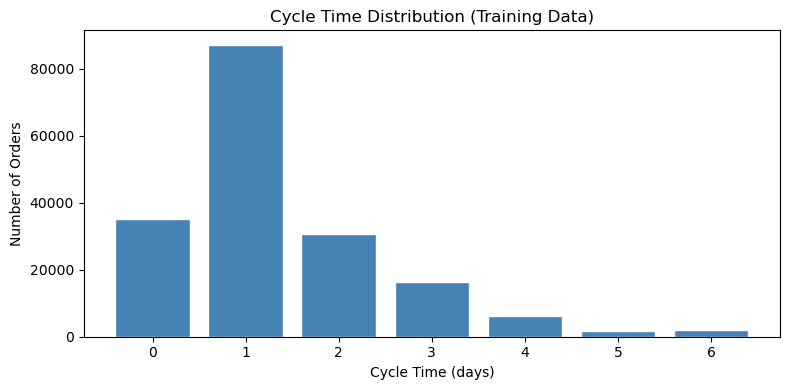

In [26]:
# Plot for target variable vs number of orders
# Majority of orders complete within 0 - 1 days
ct_counts = train["cycle_time_days"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ct_counts.index, ct_counts.values, color="steelblue", edgecolor="white")
ax.set_title("Cycle Time Distribution (Training Data)")
ax.set_xlabel("Cycle Time (days)")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.show()

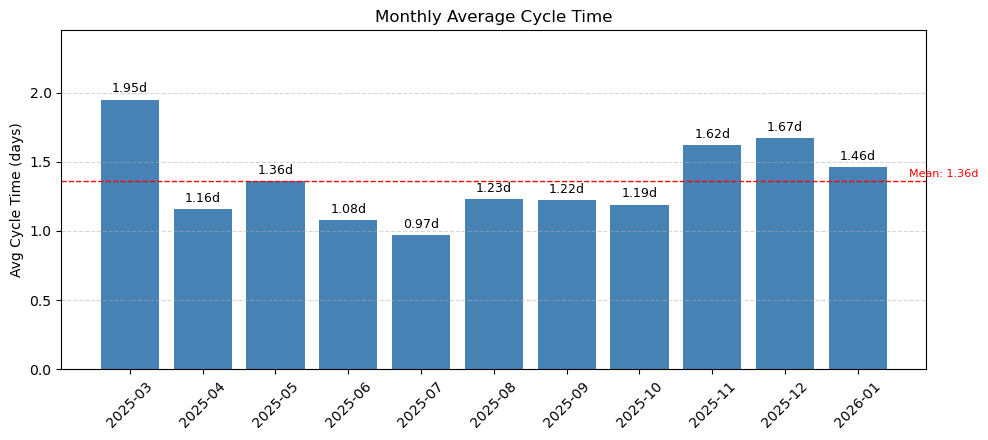

In [27]:
#### Plot between month and monthly average cycle time

monthly_mean = train.groupby(train["kit_start"].dt.to_period("M"))["cycle_time_days"].mean().round(2)
mlabels = [str(p) for p in monthly_mean.index]
mvalues = monthly_mean.values.tolist()
overall_mean = round(train["cycle_time_days"].mean(), 2)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(mlabels, mvalues, color='steelblue')

for i, val in enumerate(mvalues):
  ax.text(i, val + 0.03, f'{val}d', ha='center', va='bottom', fontsize=9)

ax.axhline(overall_mean, color='red', linestyle='--', linewidth=1)
ax.text(len(mlabels) - 0.3, overall_mean + 0.03, f'Mean: {overall_mean}d', fontsize=8, color='red')
ax.set_ylim(0, max(mvalues) + 0.5)
ax.set_ylabel('Avg Cycle Time (days)')
ax.set_title('Monthly Average Cycle Time')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Feature Engineering

In [28]:
def add_features(df):
    df = df.copy()

    df["quantity_produced"] = pd.to_numeric(df["quantity_produced"], errors="coerce")
    df["line_qty"] = pd.to_numeric(df["line_qty"], errors="coerce")
    df["order_amt"] = pd.to_numeric(df["order_amt"], errors="coerce")

    # Total estimated production time based on the product family
    df["total_expected_minutes"] = (
        df["expected_kit_minutes"] +
        df["expected_build_minutes"] +
        df["expected_burn_minutes"]
    )

    # Check if kit_start is on a factory working day
    df["is_working_day"] = (
        (df["is_weekend"] == 0) & (df["is_holiday"] == 0)
    ).astype(int)

    # Total factory hours available on kit_start date
    df["total_capacity_hours"] = df["regular_hours"] + df["ot_hours"]

    # Total production workload for this order
    df["workload"] = df["quantity_produced"] * df["total_expected_minutes"]

    # Fraction of daily capacity consumed by this order
    df["capacity_utilization"] = df["workload"] / df["total_capacity_hours"].replace(0, float('nan'))
    df["capacity_utilization"] = df["capacity_utilization"].fillna(0)

    return df


train = add_features(train)
test  = add_features(test)

#### Selecting the features and filling NaN  values

In [ ]:
feature_cols = [
    # selected features from Product features
    "expected_kit_minutes",
    "expected_build_minutes",
    "expected_burn_minutes",
    "total_expected_minutes",

    # selected features from Calendar features
    "day_of_week",
    "is_working_day",
    "is_eoq",
    "is_idc",
    "is_weekend",
    "is_holiday",

    # selected features from Capacity features
    "total_capacity_hours",
    "ot_flag",

    # selected features from product Order
    "quantity_produced",
    "line_qty",
    "order_amt",
    "is_cfi",
    "cfs_flag",

    # Engineered features
    "workload",
    "capacity_utilization",
    "download_to_kitstart_days",

    # label-encoded features
    "family_desc_enc",
    "family_parent_desc_enc",
    "lob_desc_enc",
    "buid_enc",
]

X      = train[feature_cols].copy()
y      = train["cycle_time_days"].copy()
X_test = test[feature_cols].copy()

### DAtaset splitting

In [ ]:
# Splitting the time series data by date. 
# Train: March 2025 to Dec 2025
# Validation: Jan 2026
# Inference/ test: Feb 2026 to March 2026

train_mask = train["kit_start"] <  "2026-01-01"
val_mask   = train["kit_start"] >= "2026-01-01"

X_train = X[train_mask]
X_val   = X[val_mask]
y_train = y[train_mask]
y_val   = y[val_mask]

### Implementing Random Forest model

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

### Prediction on validation data (Jan 2026)

In [ ]:
val_pred         = rf_model.predict(X_val)
val_pred_rounded = np.round(val_pred).clip(0).astype(int)

# Evaluation Metrics for the Model

mae  = mean_absolute_error(y_val, val_pred_rounded)
rmse = np.sqrt(mean_squared_error(y_val, val_pred_rounded))

print(f"\nValidation MAE  : {mae:.4f} days")
print(f"Validation RMSE : {rmse:.4f} days")

### Feature importance

In [ ]:
importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:")
print(importance_df.to_string(index=False))

In [ ]:
# Plotting the feature importance
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance_df["feature"], importance_df["importance"],
        color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Retrain on Full dataset (Train + Validation)

In [ ]:
final_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

### Predict on Inference data (test)

In [ ]:
test_pred_days = final_model.predict(X_test)
test_pred_days = np.round(test_pred_days).clip(0).astype(int)

test["predicted_cycle_time_days"] = test_pred_days
test["predicted_kit_end"] = (
    test["kit_start"] + pd.to_timedelta(test["predicted_cycle_time_days"], unit="D")
)

### Convert results to numpy array

In [ ]:
predictions = test["predicted_kit_end"].to_numpy()
print(predictions)

In [ ]:
# Saving final predicted kit end date for test data in csv format
pd.DataFrame(predictions, columns=["prediction"]).to_csv("MaheswariBollimuntha_DS_Case_PredictionsArray_2026.csv", index=False)

In [ ]:
test["predicted_cycle_time_days"].describe()

In [ ]:
 # Predicted Cycle Time Distribution for Inference Data
vc = test["predicted_cycle_time_days"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(vc.index.astype(str), vc.values, color="steelblue", edgecolor="white")

for bar, val in zip(bars, vc.values):
  pct = val / len(test) * 100
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
          f"{val:,} ({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

ax.set_title("Predicted Cycle Time Distribution (12,069 Inference Orders)")
ax.set_xlabel("Predicted Cycle Time (days)")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.show()